# Chương 2: Phân Tích Tăng Trưởng Khu Vực & Phát Hiện Bất Thường Doanh Số (Cập Nhật)

Notebook này thực hiện đúng và đầy đủ các yêu cầu phân tích của **Chương 2** trong tài liệu Storytelling:
1. **EDA**: Phân tích xu hướng doanh thu, lợi nhuận và vẽ ma trận Tăng trưởng vs Quy mô (Growth vs Scale).
2. **Phân tích Khách hàng**: Đếm số lượng Active Customers, New Customers, Returning Customers theo tháng và lãnh thổ.
3. **Data Mining - Phân cụm (Clustering)**: Sử dụng K-Means để phân cụm lãnh thổ kinh doanh dựa trên quy mô doanh thu, tốc độ tăng trưởng, độ biến động và tập khách hàng.
4. **Data Mining - Phát hiện bất thường (Anomaly Detection)**: Phân rã chuỗi thời gian và dùng Z-score trên phần dư để tìm các tháng biến động doanh số bất thường.
5. **So sánh với Forecast**: Đối chiếu thực tế với doanh thu dự báo để tính sai số dự báo (Forecast Error).
6. **Lưu kết quả**: Ghi kết quả phân tích ngược lại PostgreSQL DWH.

### 1. Cấu hình & Kết nối Database

In [12]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from statsmodels.tsa.seasonal import seasonal_decompose

# Thêm thư mục gốc vào path để import src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.common.database import get_dwh_engine

# Cấu hình biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

# Kết nối DWH
engine = get_dwh_engine()
print("Kết nối database DWH thành công!")

Kết nối database DWH thành công!


### 2. Tải Dữ Liệu Phân Tích Từ DWH

In [13]:
# Lấy dữ liệu Sales Mart kết hợp tính toán số lượng khách hàng hoạt động (Active, New, Returning) từ Fact Internet Sales
query = """
    WITH customer_first_purchase AS (
        SELECT 
            customer_key,
            MIN(order_date) as first_purchase_date
        FROM dwh.fact_internet_sales
        GROUP BY customer_key
    ),
    monthly_customer_stats AS (
        SELECT 
            TO_CHAR(f.order_date, 'YYYYMM') as month_key,
            f.territory_id,
            COUNT(DISTINCT f.customer_key) as active_customers,
            COUNT(DISTINCT CASE WHEN TO_CHAR(cfp.first_purchase_date, 'YYYYMM') = TO_CHAR(f.order_date, 'YYYYMM') THEN f.customer_key END) as new_customers
        FROM dwh.fact_internet_sales f
        JOIN customer_first_purchase cfp ON f.customer_key = cfp.customer_key
        GROUP BY TO_CHAR(f.order_date, 'YYYYMM'), f.territory_id
    )
    SELECT 
        m.month_key,
        m.territory_id,
        t.territory_name,
        t.country_code,
        SUM(m.revenue) as revenue,
        SUM(m.cogs) as cogs,
        SUM(m.gross_profit) as profit,
        SUM(m.orders) as orders,
        SUM(m.quantity) as quantity,
        COALESCE(c.active_customers, 0) as active_customers,
        COALESCE(c.new_customers, 0) as new_customers,
        COALESCE(c.active_customers, 0) - COALESCE(c.new_customers, 0) as returning_customers
    FROM mart.mart_sales_kpi_monthly m
    JOIN dwh.dim_sales_territory t ON m.territory_id = t.territory_id
    LEFT JOIN monthly_customer_stats c ON m.month_key = c.month_key AND m.territory_id = c.territory_id
    GROUP BY m.month_key, m.territory_id, t.territory_name, t.country_code, c.active_customers, c.new_customers
    ORDER BY m.month_key, m.territory_id
"""
df = pd.read_sql_query(query, engine)
print(f"Đã tải {len(df)} dòng dữ liệu từ DWH.")
df.head()

Đã tải 376 dòng dữ liệu từ DWH.


,month_key,territory_id,territory_name,country_code,revenue,cogs,profit,orders,quantity,active_customers,new_customers,returning_customers
0,202205,1,Northwest,US,97305.5951,91358.7941,5946.8010,15,96,7,7,0
1,202205,2,Northeast,US,21598.3855,23344.7976,-1746.4121,9,51,4,4,0
2,202205,3,Central,US,19243.0643,19155.0349,88.0294,10,40,4,4,0
3,202205,4,Southwest,US,104333.8017,109595.1030,-5261.3013,20,240,9,9,0
4,202205,5,Southeast,US,139164.1943,134234.6553,4929.5390,23,170,10,10,0


### 3. Khám Phá Dữ Liệu (EDA)

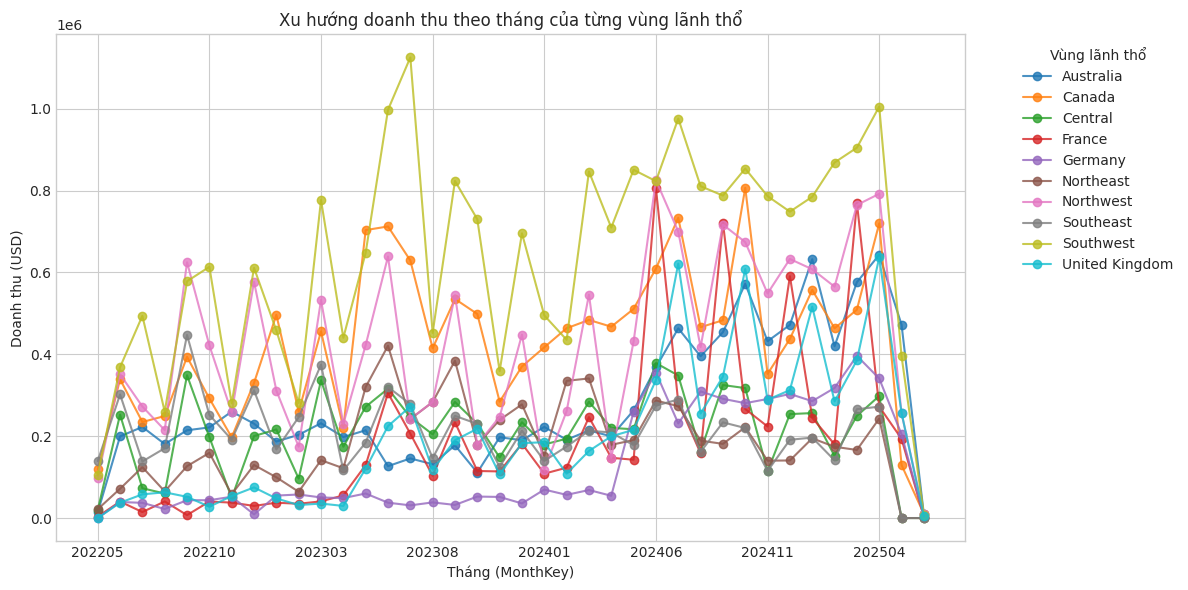

In [14]:
# 1. Vẽ xu hướng doanh thu theo khu vực lãnh thổ
df_pivot = df.pivot(index='month_key', columns='territory_name', values='revenue').fillna(0)
df_pivot.plot(kind='line', marker='o', alpha=0.8)
plt.title('Xu hướng doanh thu theo tháng của từng vùng lãnh thổ')
plt.xlabel('Tháng (MonthKey)')
plt.ylabel('Doanh thu (USD)')
plt.legend(title='Vùng lãnh thổ', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

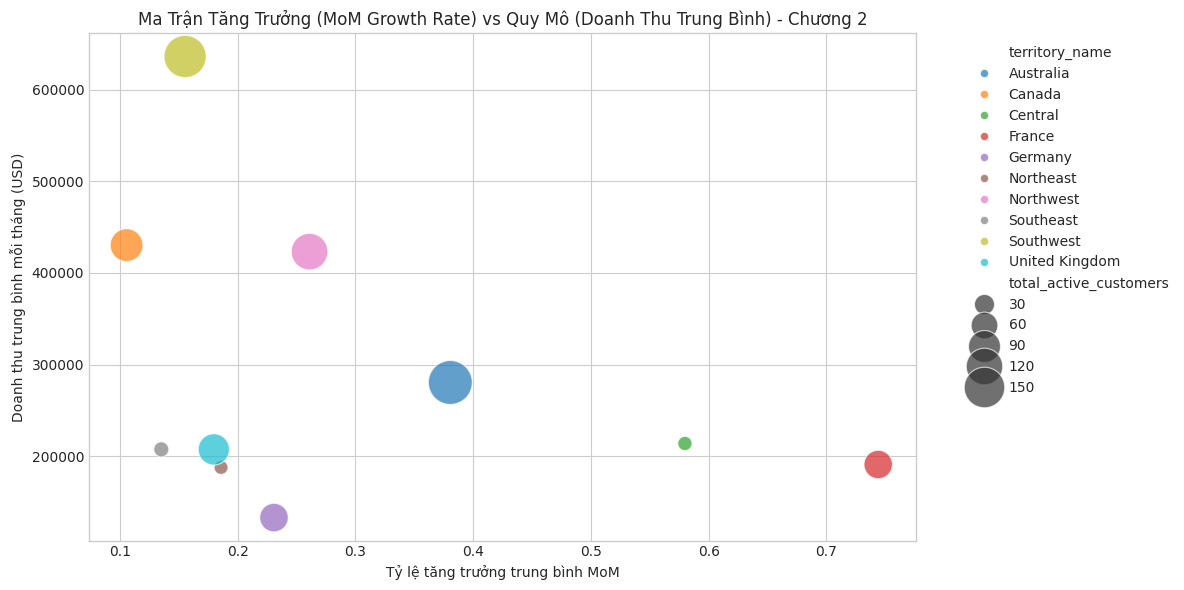

In [15]:
# 2. Tính tỷ lệ tăng trưởng doanh thu (MoM Growth) và độ biến động cho từng khu vực
df['prev_revenue'] = df.groupby('territory_id')['revenue'].shift(1)
df['mom_growth'] = (df['revenue'] - df['prev_revenue']) / df['prev_revenue']
df['mom_growth'] = df['mom_growth'].fillna(0)

# 3. Vẽ ma trận Tăng trưởng vs Quy mô (Growth vs Scale Bubble Chart)
summary = df.groupby('territory_name').agg(
    avg_revenue=('revenue', 'mean'),
    avg_growth=('mom_growth', 'mean'),
    total_profit=('profit', 'sum'),
    total_active_customers=('active_customers', 'mean')
).reset_index()

sns.scatterplot(
    data=summary, 
    x='avg_growth', 
    y='avg_revenue', 
    size='total_active_customers', 
    hue='territory_name', 
    sizes=(100, 1000), 
    alpha=0.7
)
plt.title('Ma Trận Tăng Trưởng (MoM Growth Rate) vs Quy Mô (Doanh Thu Trung Bình) - Chương 2')
plt.xlabel('Tỷ lệ tăng trưởng trung bình MoM')
plt.ylabel('Doanh thu trung bình mỗi tháng (USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Phân Cụm Lãnh Thổ Bằng K-Means (Data Mining)

In [16]:
# Chuẩn bị các đặc trưng phân cụm cho từng vùng
features_df = df.groupby(['territory_id', 'territory_name']).agg(
    mean_revenue=('revenue', 'mean'),
    mean_growth=('mom_growth', 'mean'),
    revenue_volatility=('revenue', 'std'),
    avg_active_customers=('active_customers', 'mean'),
    mean_profit=('profit', 'mean')
).reset_index()

features_df['revenue_volatility'] = features_df['revenue_volatility'].fillna(0)

# Chuẩn hóa đặc trưng
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df[['mean_revenue', 'mean_growth', 'revenue_volatility', 'avg_active_customers', 'mean_profit']])

# Huấn luyện K-Means (k=4 cụm)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
features_df['cluster_label'] = kmeans.fit_predict(scaled_features)

# Gán tên cụm dựa trên thuộc tính của 5 đặc trưng tâm cụm
centroids = features_df.groupby('cluster_label')[['mean_revenue', 'mean_growth', 'revenue_volatility', 'avg_active_customers', 'mean_profit']].mean()

cluster_names = {}
unassigned_labels = list(centroids.index)

# 1. Cụm Trụ Cột Doanh Thu: Doanh thu & lợi nhuận cao nhất
best_core = centroids.loc[unassigned_labels, 'mean_revenue'].idxmax()
cluster_names[best_core] = 'Cụm Trụ Cột Doanh Thu (Doanh Thu & Lợi Nhuận Cao Nhất)'
unassigned_labels.remove(best_core)

# 2. Cụm Ngôi Sao Mới Nổi: Tăng trưởng nhanh nhất trong các cụm còn lại
best_growth = centroids.loc[unassigned_labels, 'mean_growth'].idxmax()
cluster_names[best_growth] = 'Cụm Ngôi Sao Mới Nổi (Tăng Trưởng Nhanh Nhất)'
unassigned_labels.remove(best_growth)

# 3. Cụm Biến Động - Rủi Ro Cao: Độ dao động doanh thu cao nhất trong các cụm còn lại
best_volatile = centroids.loc[unassigned_labels, 'revenue_volatility'].idxmax()
cluster_names[best_volatile] = 'Cụm Biến Động - Rủi Ro Cao (Độ Dao Động Doanh Thu Cao Nhất)'
unassigned_labels.remove(best_volatile)

# 4. Cụm Cần Cải Tổ: Cụm cuối cùng còn lại (Quy mô doanh thu & khách hàng thấp nhất)
last_cluster = unassigned_labels[0]
cluster_names[last_cluster] = 'Cụm Cần Cải Tổ (Quy Mô & Khách Hàng Thấp Nhất)'

features_df['cluster_name'] = features_df['cluster_label'].map(cluster_names)
features_df

,territory_id,territory_name,mean_revenue,mean_growth,revenue_volatility,avg_active_customers,mean_profit,cluster_label,cluster_name
0,1,Northwest,423287.961779,0.260970,218162.487283,120.473684,35910.576118,2,Cụm Trụ Cột Doanh Thu (Doanh Thu & Lợi Nhuận C...
1,2,Northeast,187550.661649,0.185808,99466.940705,9.513514,-7283.599570,0,Cụm Cần Cải Tổ (Quy Mô & Khách Hàng Thấp Nhất)
2,3,Central,213757.000159,0.579800,96140.592131,10.405405,-3850.020344,0,Cụm Cần Cải Tổ (Quy Mô & Khách Hàng Thấp Nhất)
3,4,Southwest,636437.094758,0.155305,263497.601535,163.342105,41150.284490,2,Cụm Trụ Cột Doanh Thu (Doanh Thu & Lợi Nhuận C...
4,5,Southeast,207359.344004,0.135078,88303.705403,12.789474,-3975.195238,0,Cụm Cần Cải Tổ (Quy Mô & Khách Hàng Thấp Nhất)
5,6,Canada,430415.011970,0.105580,182756.304397,94.815789,10639.905388,2,Cụm Trụ Cột Doanh Thu (Doanh Thu & Lợi Nhuận C...
6,7,France,190830.411761,0.743967,206633.469618,69.210526,23502.491572,3,Cụm Ngôi Sao Mới Nổi (Tăng Trưởng Nhanh Nhất)
7,8,Germany,132848.853943,0.230780,126860.316148,69.756757,28189.640340,0,Cụm Cần Cải Tổ (Quy Mô & Khách Hàng Thấp Nhất)
8,9,Australia,280403.577877,0.380541,162126.825473,177.684211,90375.141553,1,Cụm Biến Động - Rủi Ro Cao (Độ Dao Động Doanh ...
9,10,United Kingdom,207316.784743,0.179680,173203.281470,85.675676,33294.841164,2,Cụm Trụ Cột Doanh Thu (Doanh Thu & Lợi Nhuận C...


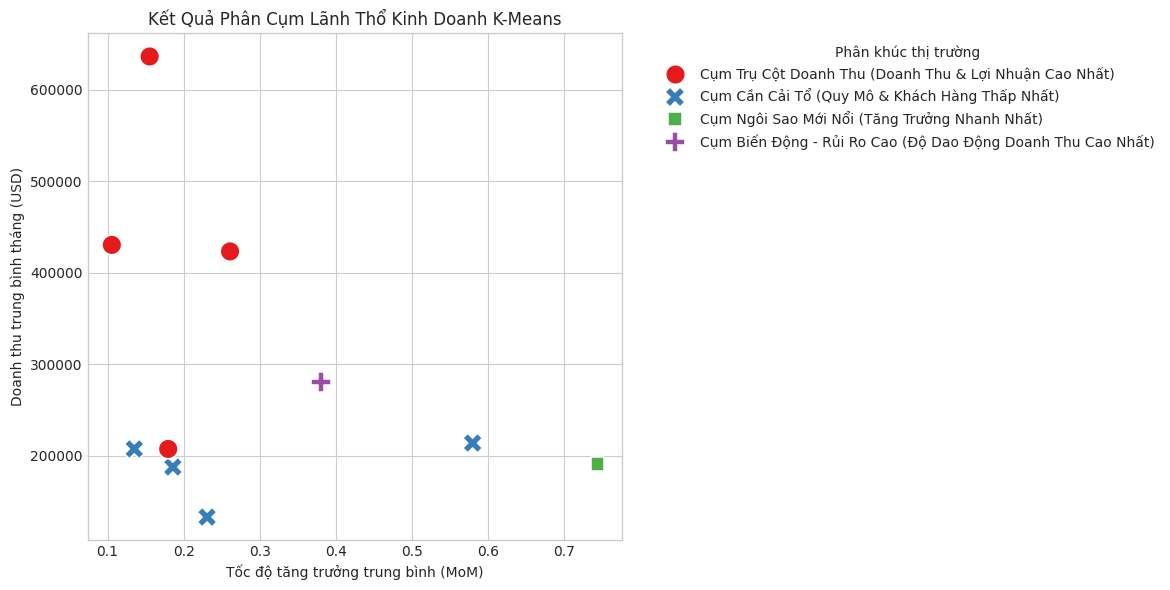

In [17]:
# Trực quan hóa kết quả phân cụm
sns.scatterplot(
    data=features_df, 
    x='mean_growth', 
    y='mean_revenue', 
    hue='cluster_name', 
    style='cluster_name',
    s=200, 
    palette='Set1'
)
plt.title('Kết Quả Phân Cụm Lãnh Thổ Kinh Doanh K-Means')
plt.xlabel('Tốc độ tăng trưởng trung bình (MoM)')
plt.ylabel('Doanh thu trung bình tháng (USD)')
plt.legend(title='Phân khúc thị trường', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5. Phát Hiện Biến Động Doanh Số Bất Thường (Anomaly Detection)

In [18]:
# Tạo bảng ghi nhận bất thường
anomaly_results = []

# Phân tích bất thường cho từng khu vực riêng biệt bằng phân rã chuỗi thời gian mùa vụ
for tid in df['territory_id'].unique():
    sub_df = df[df['territory_id'] == tid].copy()
    sub_df['date'] = pd.to_datetime(sub_df['month_key'], format='%Y%m')
    sub_df = sub_df.set_index('date').sort_index()
    
    if len(sub_df) < 12:
        # Nếu chuỗi thời gian quá ngắn, tính Z-score trực tiếp trên doanh thu
        rev_mean = sub_df['revenue'].mean()
        rev_std = sub_df['revenue'].std() or 1.0
        sub_df['residual_z'] = (sub_df['revenue'] - rev_mean) / rev_std
    else:
        # Phân rã chuỗi thời gian mùa vụ
        dec = seasonal_decompose(sub_df['revenue'], model='additive', period=12, extrapolate_trend='freq')
        residual = dec.resid
        # Tính Z-score trên phần dư
        sub_df['residual_z'] = (residual - residual.mean()) / (residual.std() or 1.0)
        
    sub_df['is_anomaly'] = np.abs(sub_df['residual_z']) > 2.0
    sub_df = sub_df.reset_index()
    anomaly_results.append(sub_df[['month_key', 'territory_id', 'residual_z', 'is_anomaly']])

anomaly_df = pd.concat(anomaly_results)
df = df.merge(anomaly_df, on=['month_key', 'territory_id'], how='left')
print(f"Tìm thấy {df['is_anomaly'].sum()} tháng biến động bất thường trên toàn bộ khu vực.")
df[df['is_anomaly'] == True].head()

Tìm thấy 20 tháng biến động bất thường trên toàn bộ khu vực.


,month_key,territory_id,territory_name,country_code,revenue,cogs,profit,orders,quantity,active_customers,new_customers,returning_customers,prev_revenue,mom_growth,residual_z,is_anomaly
22,202207,5,Southeast,US,138203.205900,1.345637e+05,3639.535900,21,155,10,10,0,301907.491400,-0.542233,-2.099674,True
119,202305,2,Northeast,US,320044.849652,3.309458e+05,-10900.924648,23,878,7,4,3,121668.652857,1.630463,2.235882,True
120,202305,3,Central,US,271827.374798,2.967191e+05,-24891.677002,25,837,8,5,3,174232.486925,0.560142,2.659779,True
123,202305,6,Canada,CA,703337.417222,7.103381e+05,-7000.710778,53,1877,30,25,5,220539.207175,2.189172,2.208694,True
131,202306,4,Southwest,US,997194.926794,1.017415e+06,-20220.052106,130,2514,80,66,14,647979.794514,0.538929,2.468002,True


### 6. So Sánh Với Doanh Thu Dự Báo (Forecast Error)

In [19]:
# Kiểm tra xem bảng dự báo ml.revenue_forecast_predictions đã tồn tại chưa
table_exists = pd.read_sql_query("""
    SELECT EXISTS (
        SELECT FROM information_schema.tables 
        WHERE table_schema = 'ml' 
        AND table_name = 'revenue_forecast_predictions'
    );
""", engine).iloc[0, 0]

if table_exists:
    print("Tìm thấy bảng dự báo. Đang nạp sai số dự báo...")
    forecast_df = pd.read_sql_query("SELECT month_key, territory_id, predicted_revenue FROM ml.revenue_forecast_predictions", engine)
    df = df.merge(forecast_df, on=['month_key', 'territory_id'], how='left')
    df['forecast_error'] = df['revenue'] - df['predicted_revenue']
else:
    print("WARNING: Chưa tìm thấy bảng dự báo ml.revenue_forecast_predictions.")
    print("-> Hãy chạy lệnh 'make train-all' ở terminal trước để huấn luyện mô hình dự báo.")
    df['predicted_revenue'] = np.nan
    df['forecast_error'] = np.nan

df.head()

Tìm thấy bảng dự báo. Đang nạp sai số dự báo...


,month_key,territory_id,territory_name,country_code,revenue,cogs,profit,orders,quantity,active_customers,new_customers,returning_customers,prev_revenue,mom_growth,residual_z,is_anomaly,predicted_revenue,forecast_error
0,202205,1,Northwest,US,97305.5951,91358.7941,5946.8010,15,96,7,7,0,NaN,0.0,-0.560683,False,NaN,NaN
1,202205,2,Northeast,US,21598.3855,23344.7976,-1746.4121,9,51,4,4,0,NaN,0.0,0.123036,False,NaN,NaN
2,202205,3,Central,US,19243.0643,19155.0349,88.0294,10,40,4,4,0,NaN,0.0,-0.837979,False,NaN,NaN
3,202205,4,Southwest,US,104333.8017,109595.1030,-5261.3013,20,240,9,9,0,NaN,0.0,-0.643669,False,NaN,NaN
4,202205,5,Southeast,US,139164.1943,134234.6553,4929.5390,23,170,10,10,0,NaN,0.0,-0.545644,False,NaN,NaN


### 7. Ghi Kết Quả Vào Database DWH Phục Vụ Superset

In [20]:
# Merge kết quả phân cụm và bất thường
output_db = df.merge(
    features_df[['territory_id', 'cluster_label', 'cluster_name']], 
    on='territory_id', 
    how='left'
)

# Chọn các cột đúng chuẩn của Storytelling
output_db = output_db[[
    'month_key', 'territory_id', 'revenue', 'profit', 'mom_growth', 'orders',
    'active_customers', 'new_customers', 'returning_customers',
    'cluster_label', 'cluster_name', 'residual_z', 'is_anomaly',
    'predicted_revenue', 'forecast_error'
]]

output_db['is_anomaly'] = output_db['is_anomaly'].astype(int)

# Ghi đè vào bảng kết quả của schema ml
output_db.to_sql(
    name='territory_analysis_results', 
    con=engine, 
    schema='ml', 
    if_exists='replace', 
    index=False
)

print("Thành công: Đã lưu bảng kết quả hoàn chỉnh vào ml.territory_analysis_results!")

Thành công: Đã lưu bảng kết quả hoàn chỉnh vào ml.territory_analysis_results!
